1. Loading and cleaning metadata TSV...
2. Extracting & aggregating embeddings from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/data/embeddings/ofd_tailhip_20260226-205043.h5...
Extracted mean pooled embeddings of dimension 256 for 3224 recordings.
3. Merging with metadata...

4. Filtering Data & Setup
Removed 'B6CAST-129SPWK-F2' and strains with < 20 recordings.
Remaining valid samples: 2970
Remaining unique strains: 77

5. 5-Fold Cross-Validation Leaderboard
Evaluating Random Forest...
  -> Mean Accuracy: 78.22% (± 1.76%)
Evaluating Extra Trees...
  -> Mean Accuracy: 79.49% (± 1.21%)
Evaluating Logistic Regression...
  -> Mean Accuracy: 90.24% (± 0.59%)
Evaluating SVM (RBF)...
  -> Mean Accuracy: 83.77% (± 1.53%)
Evaluating SVM (Linear)...
  -> Mean Accuracy: 90.30% (± 0.96%)
Evaluating K-Nearest Neighbors...
  -> Mean Accuracy: 72.79% (± 1.33%)


/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `nam

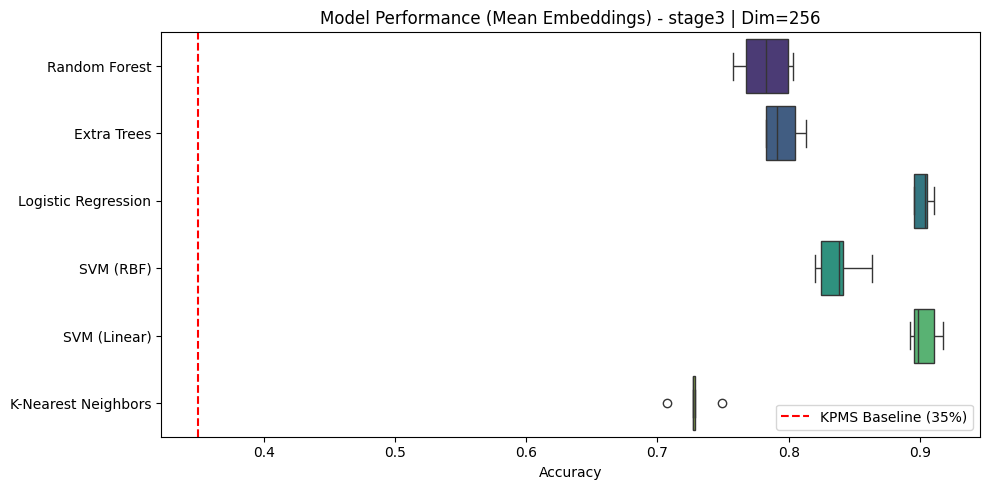


6. Detailed Analysis of the Best Model

Classification Report (Top 5 Strains):
               precision    recall  f1-score   support

       FVB/NJ       1.00      1.00      1.00        14
       DBA/2J       1.00      0.77      0.87        13
CC027/GeniUnc       1.00      0.89      0.94         9
    C57BR/cdJ       0.82      1.00      0.90         9
        BXD62       1.00      0.78      0.88         9

    micro avg       0.96      0.89      0.92        54
    macro avg       0.96      0.89      0.92        54
 weighted avg       0.97      0.89      0.92        54



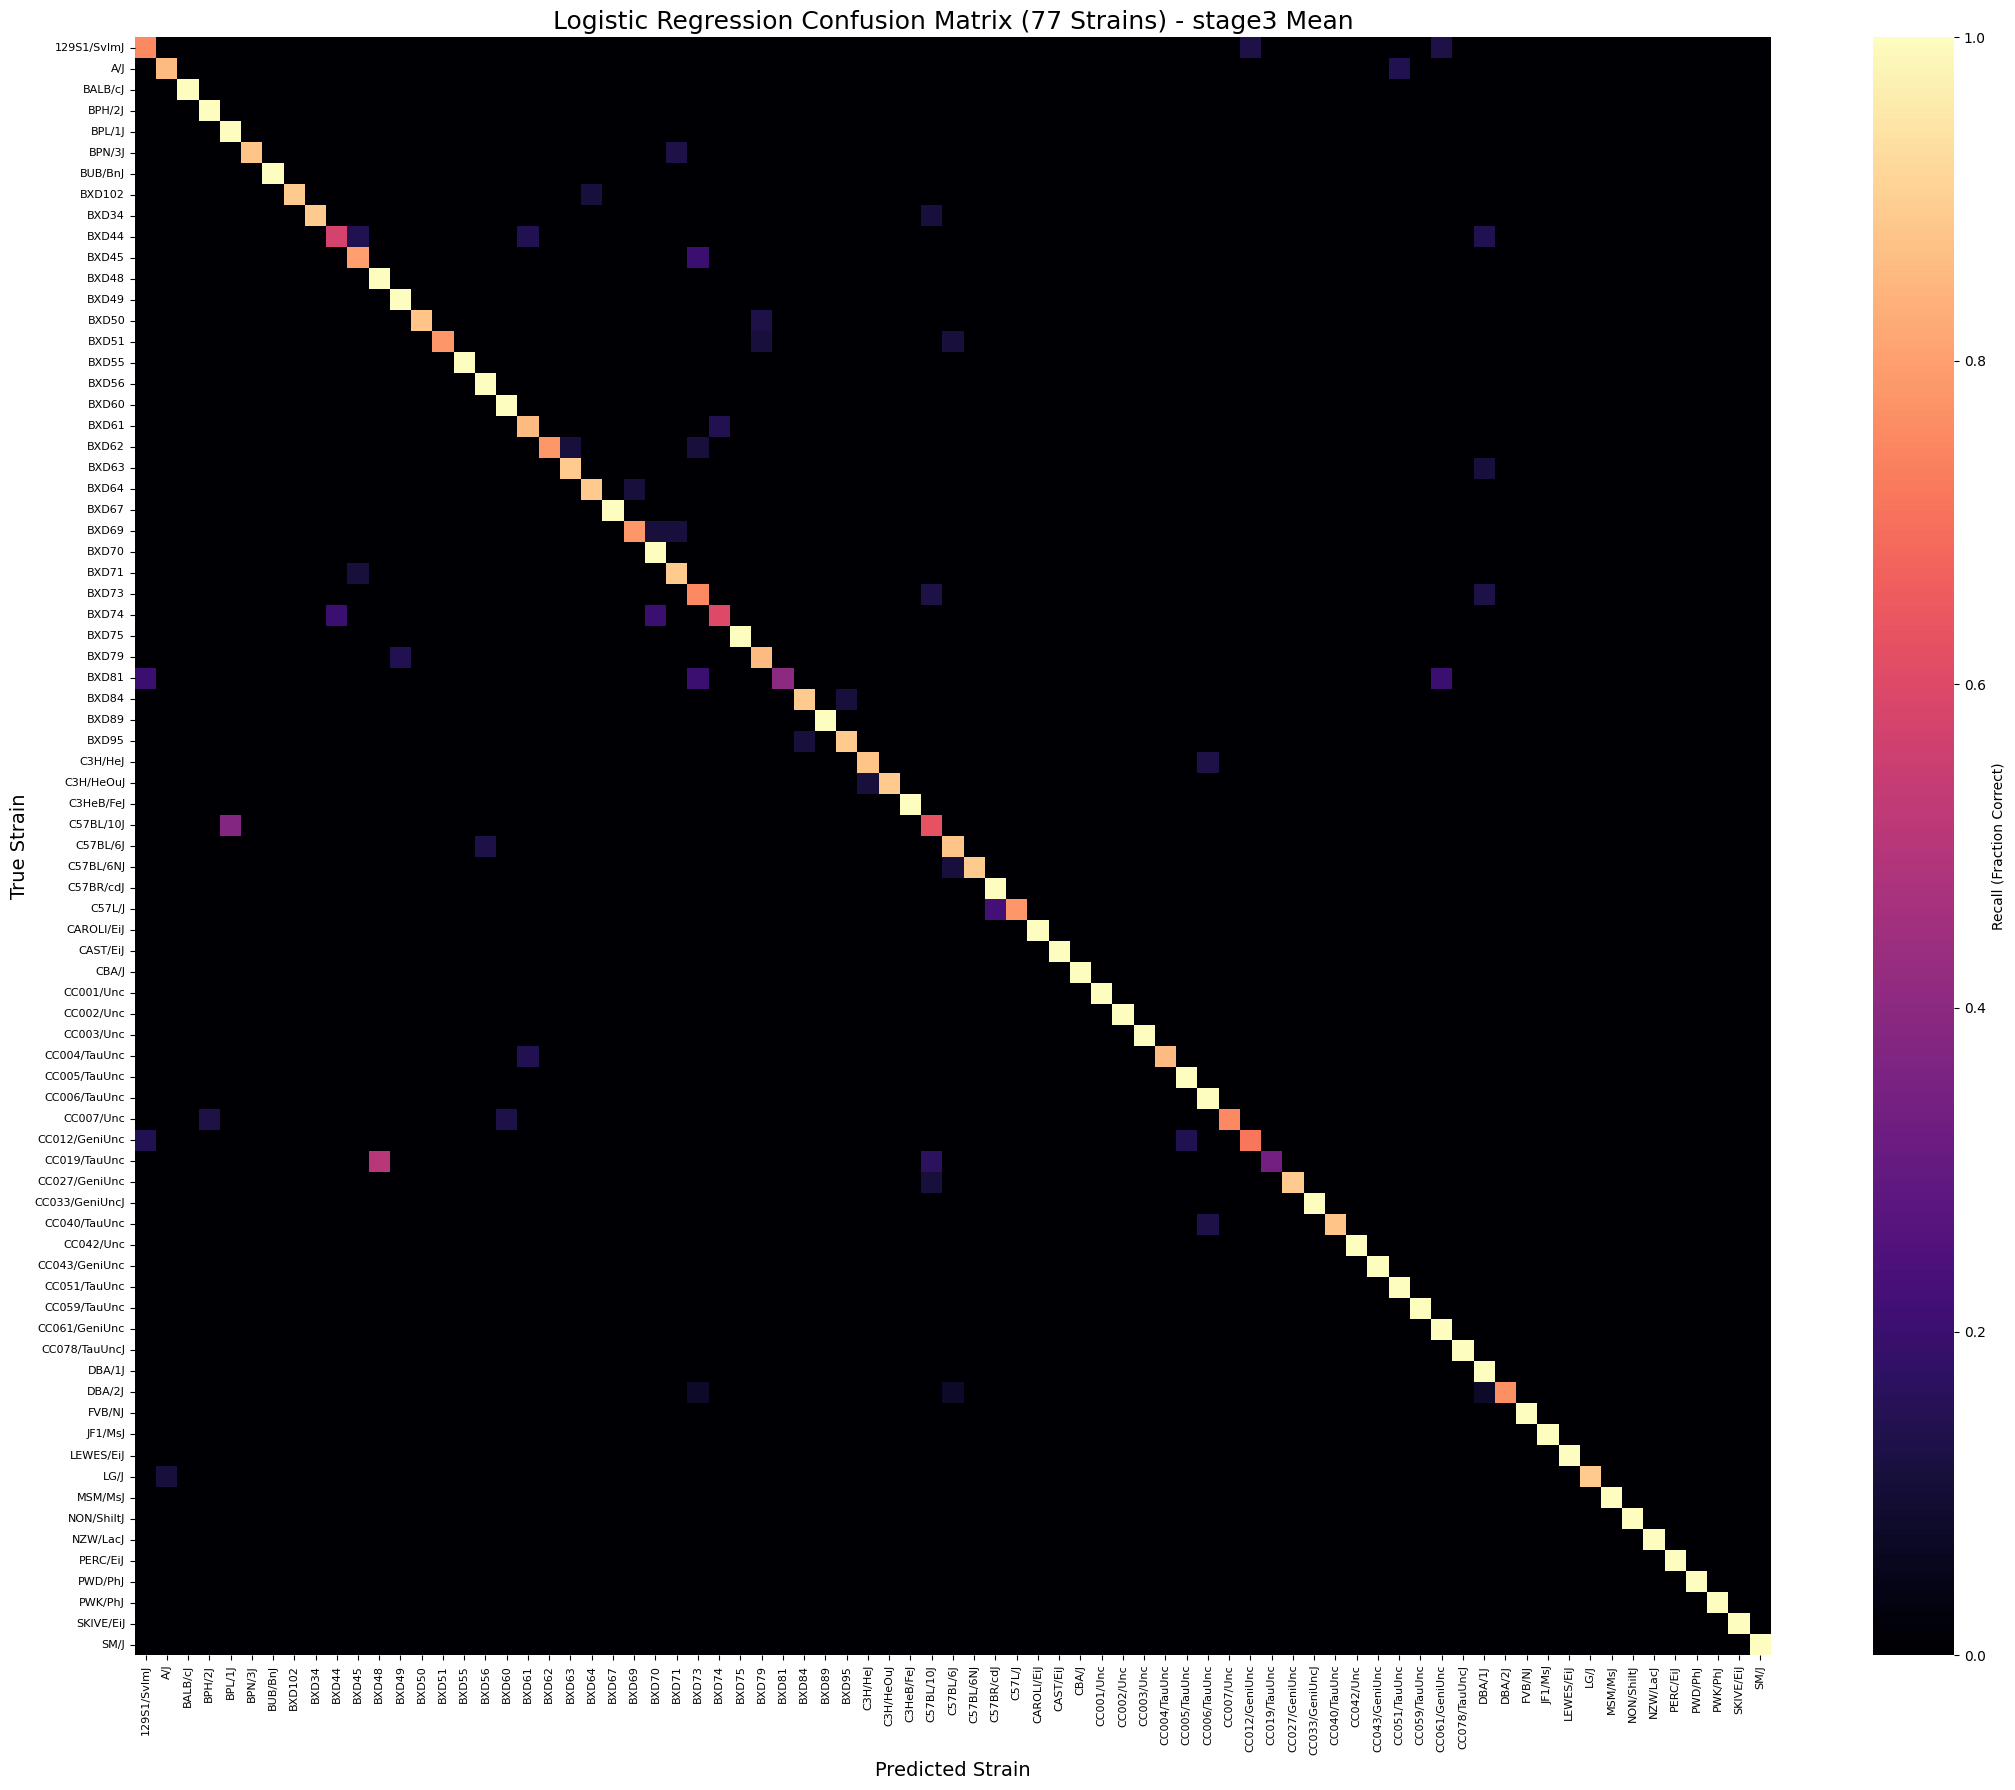

In [7]:
# %% [markdown]
# # Strain Classification using Aggregated hBehaveMAE Embeddings
# This notebook loads frame-level continuous embeddings, applies temporal pooling (mean or median) to create a single global embedding per recording, and evaluates strain classification performance.

# %%
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path
# --- Configuration ---
# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

PROJECT_ROOT = Path("/scratch/michal/projects/dvc_ofd_2025")

# Pointing to the NEWLY restructured hBehaveMAE embedding file
EMB_H5_PATH = BASE_DIR / "data/embeddings/ofd_tailhip_20260226-205043.h5"
META_TSV_PATH = PROJECT_ROOT / "data/raw/openfield_ORT/hdp_meta.tsv"

STAGE = "stage3"       # Which encoder stage to use (stage1, stage2, or stage3)
AGG_METHOD = "mean"    # 'mean' or 'median'

print("1. Loading and cleaning metadata TSV...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

print(f"2. Extracting & aggregating embeddings from {EMB_H5_PATH}...")
features_list = []

with h5py.File(EMB_H5_PATH, 'r') as f:
    video_names = list(f.keys())
    
    for vid in video_names:
        parts = vid.split('_')
        if len(parts) < 3:
            continue
            
        animal_id = parts[0]
        exp_stage = parts[1]
        age = parts[2]
        
        # In the h5 file, the stages are usually saved directly under the video group
        if STAGE not in f[vid]:
            print(f"Warning: {STAGE} not found for {vid}")
            continue
            
        # Load frame-level embeddings: shape (num_frames, embedding_dim)
        embs = f[vid][STAGE][:] 
        
        # Temporal Pooling: Collapse the time dimension to a single vector
        if AGG_METHOD == "mean":
            agg_emb = np.mean(embs, axis=0)
        elif AGG_METHOD == "median":
            agg_emb = np.median(embs, axis=0)
        else:
            raise ValueError("AGG_METHOD must be 'mean' or 'median'")
            
        row_data = {
            'video_name': vid,
            'animal_id': animal_id,
            'exp_stage': exp_stage,
            'age': age
        }
        
        # Dynamically add all embedding dimensions to the row
        embedding_dim = len(agg_emb)
        for i in range(embedding_dim):
            row_data[f'emb_{i}'] = agg_emb[i]
            
        features_list.append(row_data)

emb_df = pd.DataFrame(features_list)
print(f"Extracted {AGG_METHOD} pooled embeddings of dimension {embedding_dim} for {len(emb_df)} recordings.")

print("3. Merging with metadata...")
master_df = pd.merge(emb_df, meta_df, on='animal_id', how='inner')

# %%
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("\n" + "="*50)
print("4. Filtering Data & Setup")
print("="*50)

# 1. Drop rows with missing strain info
df_filtered = master_df.dropna(subset=['strain']).copy()

# 2. Remove the "fake" over-represented strain
fake_strain = 'B6CAST-129SPWK-F2'
df_filtered = df_filtered[df_filtered['strain'] != fake_strain]

# 3. Remove strains with fewer than 20 recordings
strain_counts = df_filtered['strain'].value_counts()
valid_strains = strain_counts[strain_counts >= 20].index
df_filtered = df_filtered[df_filtered['strain'].isin(valid_strains)]

print(f"Removed '{fake_strain}' and strains with < 20 recordings.")
print(f"Remaining valid samples: {len(df_filtered)}")
print(f"Remaining unique strains: {len(valid_strains)}")

# Extract Features (X) and Target (y)
feature_cols = [f'emb_{i}' for i in range(embedding_dim)]
X = df_filtered[feature_cols].values
y = df_filtered['strain'].values

print("\n" + "="*50)
print("5. 5-Fold Cross-Validation Leaderboard")
print("="*50)

# Setup models. 
# Continuous embeddings heavily rely on StandardScaler for linear models/SVMs.
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
    "SVM (Linear)": make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced')),
    "K-Nearest Neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=1) 
    results[name] = scores
    print(f"  -> Mean Accuracy: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# --- Plot the Leaderboard ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=pd.DataFrame(results), orient="h", palette="viridis")
plt.title(f"Model Performance ({AGG_METHOD.capitalize()} Embeddings) - {STAGE} | Dim={embedding_dim}")
plt.xlabel("Accuracy")
plt.axvline(x=0.35, color='red', linestyle='--', label='KPMS Baseline (35%)')
plt.legend()
plt.tight_layout()
plt.show()

# %%
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "="*50)
print("6. Detailed Analysis of the Best Model")
print("="*50)

# Create a single Train/Test split for deep dive
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Based on usual continuous embedding performance, Logistic Regression or Linear SVM often wins.
# Let's use Logistic Regression for the detailed matrix.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

top_strains = pd.Series(y_test).value_counts().nlargest(5).index.tolist()
print("\nClassification Report (Top 5 Strains):")
print(classification_report(y_test, y_pred, labels=top_strains, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_, normalize='true')

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm, 
    cmap='magma', 
    xticklabels=clf.classes_, 
    yticklabels=clf.classes_,
    cbar_kws={'label': 'Recall (Fraction Correct)'}
)

plt.title(f"Logistic Regression Confusion Matrix ({len(clf.classes_)} Strains) - {STAGE} {AGG_METHOD.capitalize()}", fontsize=18)
plt.xlabel("Predicted Strain", fontsize=14)
plt.ylabel("True Strain", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [2]:
# %% [markdown]
# # Strain Classification using Aggregated hBehaveMAE Embeddings (All Stages)
# This notebook extracts embeddings for Stage 1, Stage 2, and Stage 3 in a single pass, applies temporal pooling, and compares their informativeness for strain classification.

# %%
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

PROJECT_ROOT = Path("/scratch/michal/projects/dvc_ofd_2025")

# --- Configuration ---
# Pointing to the NEWLY restructured hBehaveMAE embedding file location
EMB_H5_PATH = BASE_DIR / "data/embeddings/ofd_tailhip_20260226-205043.h5"
META_TSV_PATH = PROJECT_ROOT / "data/raw/openfield_ORT/hdp_meta.tsv"

STAGES = ["stage1", "stage2", "stage3"]
AGG_METHOD = "mean"    # 'mean' or 'median'

print("1. Loading and cleaning metadata TSV...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

print(f"2. Extracting & aggregating {STAGES} embeddings from {EMB_H5_PATH}...")
# Create a dictionary to hold the feature lists for each stage separately
features_dict = {stage: [] for stage in STAGES}

with h5py.File(EMB_H5_PATH, 'r') as f:
    video_names = list(f.keys())
    
    for vid in video_names:
        parts = vid.split('_')
        if len(parts) < 3:
            continue
            
        animal_id = parts[0]
        exp_stage = parts[1]
        age = parts[2]
        
        for stage in STAGES:
            if stage not in f[vid]:
                continue
                
            # Load frame-level embeddings
            embs = f[vid][stage][:] 
            
            # Temporal Pooling
            if AGG_METHOD == "mean":
                agg_emb = np.mean(embs, axis=0)
            elif AGG_METHOD == "median":
                agg_emb = np.median(embs, axis=0)
                
            row_data = {
                'video_name': vid,
                'animal_id': animal_id,
                'exp_stage': exp_stage,
                'age': age
            }
            
            # Note: Different stages usually have different embedding dimensions!
            # We dynamically add them based on the length of agg_emb
            for i in range(len(agg_emb)):
                row_data[f'emb_{i}'] = agg_emb[i]
                
            features_dict[stage].append(row_data)

print("\n3. Merging with metadata and filtering...")
stage_dfs = {}

for stage in STAGES:
    # Convert to DataFrame
    df = pd.DataFrame(features_dict[stage])
    emb_dim = len([c for c in df.columns if c.startswith('emb_')])
    print(f" -> {stage.capitalize()}: Extracted dimension {emb_dim} for {len(df)} recordings.")
    
    # Merge
    master_df = pd.merge(df, meta_df, on='animal_id', how='inner')
    
    # Filter missing strains and the fake strain
    master_df = master_df.dropna(subset=['strain'])
    master_df = master_df[master_df['strain'] != 'B6CAST-129SPWK-F2']
    
    # Keep only strains with >= 20 recordings
    counts = master_df['strain'].value_counts()
    valid_strains = counts[counts >= 20].index
    master_df = master_df[master_df['strain'].isin(valid_strains)]
    
    stage_dfs[stage] = master_df

print(f"\nRemaining valid samples per stage: {len(stage_dfs[STAGES[0]])}")
print(f"Remaining unique strains: {len(valid_strains)}")


1. Loading and cleaning metadata TSV...
2. Extracting & aggregating ['stage1', 'stage2', 'stage3'] embeddings from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/data/embeddings/ofd_tailhip_20260226-205043.h5...

3. Merging with metadata and filtering...
 -> Stage1: Extracted dimension 128 for 3224 recordings.
 -> Stage2: Extracted dimension 192 for 3224 recordings.
 -> Stage3: Extracted dimension 256 for 3224 recordings.

Remaining valid samples per stage: 2970
Remaining unique strains: 77


In [ ]:

# %%
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("\n" + "="*50)
print("4. 5-Fold Cross-Validation Multi-Stage Leaderboard")
print("="*50)

# We will store all results in a flat list to make Seaborn grouping easy
all_cv_results = []

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
    "SVM (Linear)": make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced')),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for stage in STAGES:
    print(f"\nEvaluating {stage.upper()}...")
    df = stage_dfs[stage]
    
    # Extract Features (X) dynamically since dims change per stage
    feature_cols = [c for c in df.columns if c.startswith('emb_')]
    X = df[feature_cols].values
    y = df['strain'].values
    
    for name, model in models.items():
        # n_jobs=-1 inside cross_val_score runs the folds in parallel
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1) 
        print(f"  -> {name}: Mean Accuracy {scores.mean()*100:.2f}%")
        
        for fold_idx, score in enumerate(scores):
            all_cv_results.append({
                'Stage': stage.capitalize(),
                'Model': name,
                'Accuracy': score,
                'Fold': fold_idx
            })

# --- Plot the Grouped Leaderboard ---
results_df = pd.DataFrame(all_cv_results)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=results_df, 
    x='Accuracy', 
    y='Model', 
    hue='Stage', 
    palette="viridis"
)

plt.title(f"Model Performance by hBehaveMAE Stage ({AGG_METHOD.capitalize()} Pooling)", fontsize=16)
plt.xlabel("Accuracy", fontsize=14)
plt.ylabel("")
plt.axvline(x=0.35, color='red', linestyle='--', label='KPMS Baseline (35%)')
plt.legend(title='Encoder Stage', loc='lower right')
plt.tight_layout()
plt.show()

# %%
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("\n" + "="*50)
print("5. Detailed Analysis of the BEST Stage + Model combination")
print("="*50)

# Based on the plot above, decide which stage performed best (usually stage3 or stage2).
# Let's dynamically pick the best stage and model based on the mean CV scores
mean_scores = results_df.groupby(['Stage', 'Model'])['Accuracy'].mean().reset_index()
best_combo = mean_scores.loc[mean_scores['Accuracy'].idxmax()]

BEST_STAGE = best_combo['Stage'].lower()
BEST_MODEL_NAME = best_combo['Model']
print(f"Auto-selected best combination: {BEST_STAGE.upper()} with {BEST_MODEL_NAME} (Accuracy: {best_combo['Accuracy']*100:.2f}%)")

df_best = stage_dfs[BEST_STAGE]
X_best = df_best[[c for c in df_best.columns if c.startswith('emb_')]].values
y_best = df_best['strain'].values

# Create a single Train/Test split for deep dive
X_train, X_test, y_train, y_test = train_test_split(X_best, y_best, test_size=0.2, random_state=42, stratify=y_best)

# Retrieve the actual model object to train
clf = models[BEST_MODEL_NAME]
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

top_strains = pd.Series(y_test).value_counts().nlargest(5).index.tolist()
print("\nClassification Report (Top 5 Strains):")
print(classification_report(y_test, y_pred, labels=top_strains, zero_division=0))

# Confusion Matrix
classes = getattr(clf, "classes_", np.unique(y_train)) # Handles pipeline class extraction
cm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm, 
    cmap='magma', 
    xticklabels=classes, 
    yticklabels=classes,
    cbar_kws={'label': 'Recall (Fraction Correct)'}
)

plt.title(f"{BEST_MODEL_NAME} Confusion Matrix ({len(classes)} Strains) - {BEST_STAGE.capitalize()}", fontsize=18)
plt.xlabel("Predicted Strain", fontsize=14)
plt.ylabel("True Strain", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

1. Loading frame-level embeddings for stage2...
Total frame-level embeddings loaded: 56332088 frames, 192 dimensions.

2. Scaling and fitting PCA on all frames...
PCA fitting complete!


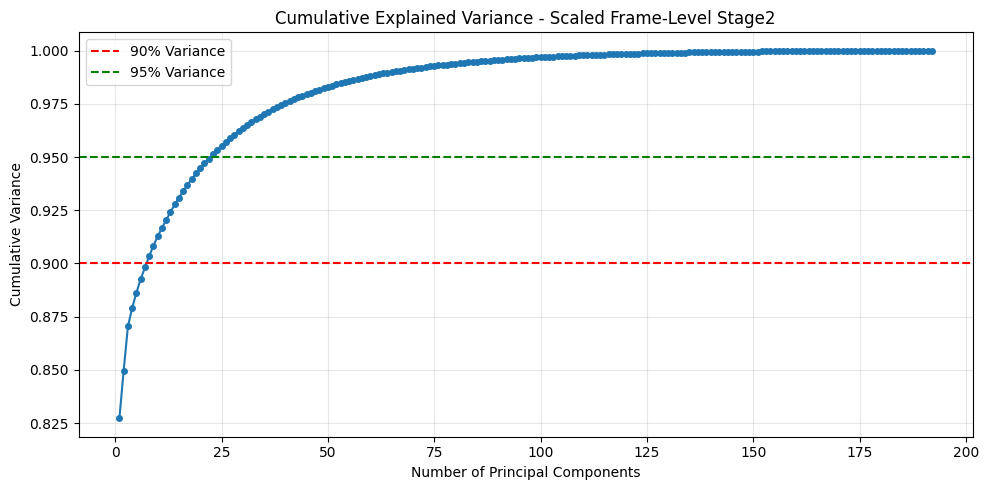

In [3]:
# %% [markdown]
# # Step 1: Fit Frame-Level PCA (Scaled)
# This cell loads all frame embeddings, standardizes them, fits the PCA, and plots the cumulative explained variance.

# %%
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

# --- Configuration ---
# Pointing to the NEWLY restructured hBehaveMAE embedding file location
EMB_H5_PATH = BASE_DIR / "data/embeddings/ofd_tailhip_20260226-205043.h5"
STAGE = "stage2"  # Choose stage1, stage2, or stage3

print(f"1. Loading frame-level embeddings for {STAGE}...")
frame_dict = {}       
all_frames_list = []  

with h5py.File(EMB_H5_PATH, 'r') as f:
    for vid in f.keys():
        if STAGE in f[vid]:
            embs = f[vid][STAGE][:]
            frame_dict[vid] = embs
            all_frames_list.append(embs)

all_frames = np.vstack(all_frames_list)
print(f"Total frame-level embeddings loaded: {all_frames.shape[0]} frames, {all_frames.shape[1]} dimensions.")

print("\n2. Scaling and fitting PCA on all frames...")
# Create a pipeline to scale FIRST, then apply PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42))
])

# Fit the pipeline
pca_pipeline.fit(all_frames)

# Extract the PCA step to get the variance metrics
pca = pca_pipeline.named_steps['pca']

print("PCA fitting complete!")

# --- Plot Explained Variance ---
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.title(f"Cumulative Explained Variance - Scaled Frame-Level {STAGE.capitalize()}")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Free up memory
del all_frames
del all_frames_list

1. Loading frame-level embeddings for stage2...
Total frame-level embeddings loaded: 56332088 frames, 192 dimensions.

2. Scaling and fitting PCA on all frames...
PCA fitting complete!


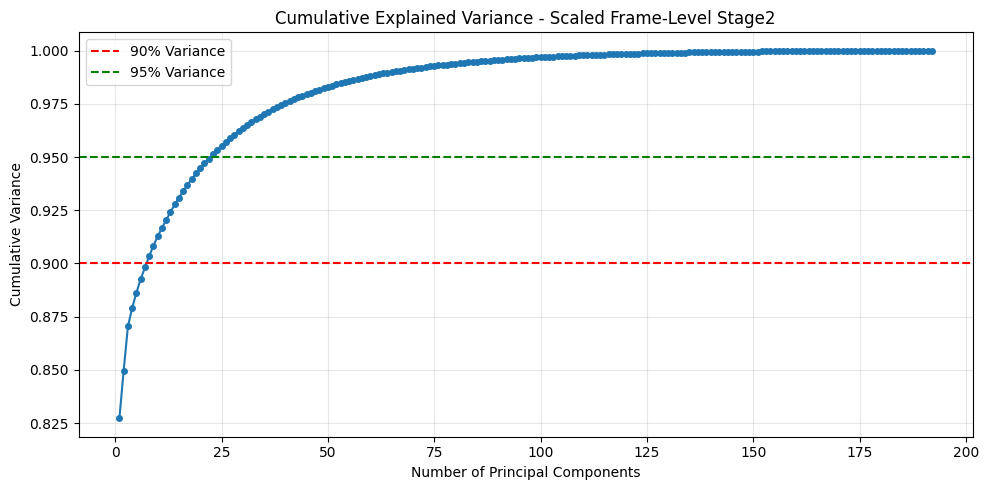

In [ ]:
# %% [markdown]
# # Step 1: Fit Frame-Level PCA (Scaled)
# This cell loads all frame embeddings, standardizes them, fits the PCA, and plots the cumulative explained variance.

# %%
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- Configuration ---
EMB_H5_PATH = "/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/data/shuffle-3_split-train/ofd_tailhip_20260226-205043.h5"
STAGE = "stage2"  # Choose stage1, stage2, or stage3

print(f"1. Loading frame-level embeddings for {STAGE}...")
frame_dict = {}       
all_frames_list = []  

with h5py.File(EMB_H5_PATH, 'r') as f:
    for vid in f.keys():
        if STAGE in f[vid]:
            embs = f[vid][STAGE][:]
            frame_dict[vid] = embs
            all_frames_list.append(embs)

all_frames = np.vstack(all_frames_list)
print(f"Total frame-level embeddings loaded: {all_frames.shape[0]} frames, {all_frames.shape[1]} dimensions.")

print("\n2. Scaling and fitting PCA on all frames...")
# Create a pipeline to scale FIRST, then apply PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42))
])

# Fit the pipeline
pca_pipeline.fit(all_frames)

# Extract the PCA step to get the variance metrics
pca = pca_pipeline.named_steps['pca']

print("PCA fitting complete!")

# --- Plot Explained Variance ---
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.title(f"Cumulative Explained Variance - Scaled Frame-Level {STAGE.capitalize()}")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Free up memory
del all_frames
del all_frames_list

1. Transforming frames (Keeping 8 PCs) and Pooling via mean...
2. Merging with metadata and filtering...
Valid recordings remaining: 2970

3. 5-Fold Cross-Validation (Stage2 | PCs=8 | Mean)
Evaluating Random Forest...
  -> Mean Accuracy: 49.83% (± 1.60%)
Evaluating Logistic Regression...
  -> Mean Accuracy: 43.64% (± 1.98%)
Evaluating SVM (RBF)...
  -> Mean Accuracy: 49.02% (± 2.04%)
Evaluating SVM (Linear)...
  -> Mean Accuracy: 46.57% (± 1.63%)


/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `nam

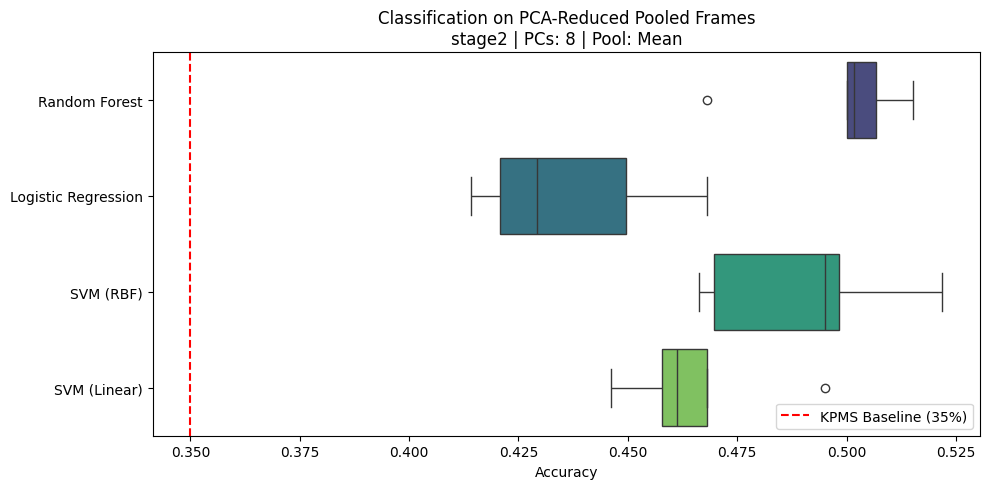

In [4]:
# %% [markdown]
# # Step 2: Transform, Pool, and Classify
# Set N_COMPONENTS based on the plot above. Transforms the frames, pools them per recording, and evaluates.

# %%
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# --- Configuration ---
N_COMPONENTS = 8      # <--- CHANGE THIS based on your PCA plot
AGG_METHOD = "mean"    # 'mean' or 'median'
META_TSV_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/raw/openfield_ORT/hdp_meta.tsv"

print(f"1. Transforming frames (Keeping {N_COMPONENTS} PCs) and Pooling via {AGG_METHOD}...")
features_list = []

for vid, frames in frame_dict.items():
    # Transform frames using the fitted PCA, and immediately slice the top N components
    # reduced_frames = pca.transform(frames)[:, :N_COMPONENTS]
    reduced_frames = pca_pipeline.transform(frames)[:, :N_COMPONENTS]
    
    # Pool across time
    if AGG_METHOD == "mean":
        agg_emb = np.mean(reduced_frames, axis=0)
    elif AGG_METHOD == "median":
        agg_emb = np.median(reduced_frames, axis=0)
        
    parts = vid.split('_')
    if len(parts) >= 3:
        row_data = {
            'video_name': vid,
            'animal_id': parts[0],
            'exp_stage': parts[1],
            'age': parts[2]
        }
        for i in range(N_COMPONENTS):
            row_data[f'pc_{i}'] = agg_emb[i]
        features_list.append(row_data)

df_emb = pd.DataFrame(features_list)

print("2. Merging with metadata and filtering...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

master_df = pd.merge(df_emb, meta_df, on='animal_id', how='inner')
master_df = master_df.dropna(subset=['strain'])
master_df = master_df[master_df['strain'] != 'B6CAST-129SPWK-F2']

counts = master_df['strain'].value_counts()
valid_strains = counts[counts >= 20].index
master_df = master_df[master_df['strain'].isin(valid_strains)]

print(f"Valid recordings remaining: {len(master_df)}")

# Extract Features and Target
feature_cols = [f'pc_{i}' for i in range(N_COMPONENTS)]
X = master_df[feature_cols].values
y = master_df['strain'].values

print("\n" + "="*50)
print(f"3. 5-Fold Cross-Validation ({STAGE.capitalize()} | PCs={N_COMPONENTS} | {AGG_METHOD.capitalize()})")
print("="*50)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
    "SVM (Linear)": make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced'))
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1) 
    results[name] = scores
    print(f"  -> Mean Accuracy: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# --- Plot Results ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=pd.DataFrame(results), orient="h", palette="viridis")
plt.title(f"Classification on PCA-Reduced Pooled Frames\n{STAGE} | PCs: {N_COMPONENTS} | Pool: {AGG_METHOD.capitalize()}")
plt.xlabel("Accuracy")
plt.axvline(x=0.35, color='red', linestyle='--', label='KPMS Baseline (35%)')
plt.legend()
plt.tight_layout()
plt.show()

1. Transforming frames (Keeping 24 PCs) and Pooling via mean...
2. Merging with metadata and filtering...
Valid recordings remaining: 2970

3. 5-Fold Cross-Validation (Stage2 | PCs=24 | Mean)
Evaluating Random Forest...
  -> Mean Accuracy: 77.34% (± 1.12%)
Evaluating Logistic Regression...
  -> Mean Accuracy: 78.55% (± 0.82%)
Evaluating SVM (RBF)...
  -> Mean Accuracy: 81.45% (± 1.35%)
Evaluating SVM (Linear)...
  -> Mean Accuracy: 81.38% (± 1.09%)


/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `nam

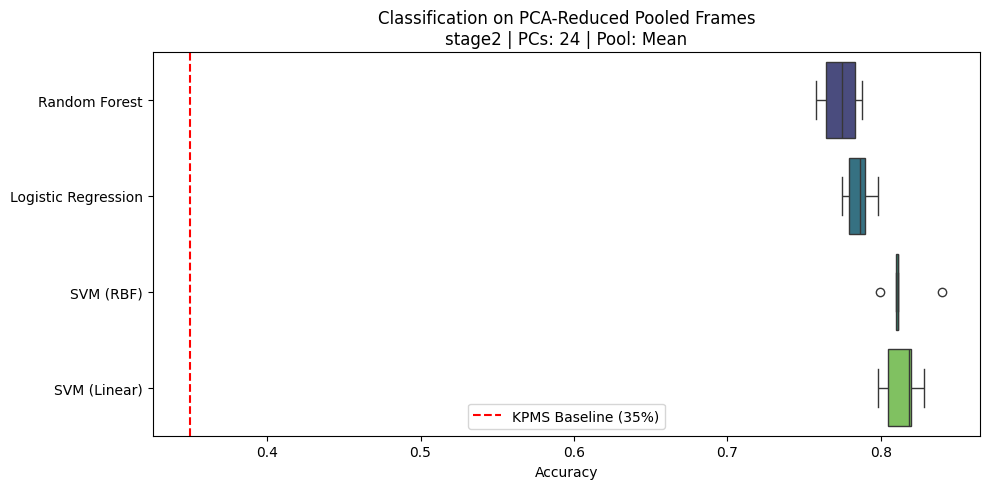

In [5]:
# %% [markdown]
# # Step 2: Transform, Pool, and Classify
# Set N_COMPONENTS based on the plot above. Transforms the frames, pools them per recording, and evaluates.

# %%
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# --- Configuration ---
N_COMPONENTS = 24      # <--- CHANGE THIS based on your PCA plot
AGG_METHOD = "mean"    # 'mean' or 'median'
META_TSV_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/raw/openfield_ORT/hdp_meta.tsv"

print(f"1. Transforming frames (Keeping {N_COMPONENTS} PCs) and Pooling via {AGG_METHOD}...")
features_list = []

for vid, frames in frame_dict.items():
    # Transform frames using the fitted PCA, and immediately slice the top N components
    # reduced_frames = pca.transform(frames)[:, :N_COMPONENTS]
    reduced_frames = pca_pipeline.transform(frames)[:, :N_COMPONENTS]
    
    # Pool across time
    if AGG_METHOD == "mean":
        agg_emb = np.mean(reduced_frames, axis=0)
    elif AGG_METHOD == "median":
        agg_emb = np.median(reduced_frames, axis=0)
        
    parts = vid.split('_')
    if len(parts) >= 3:
        row_data = {
            'video_name': vid,
            'animal_id': parts[0],
            'exp_stage': parts[1],
            'age': parts[2]
        }
        for i in range(N_COMPONENTS):
            row_data[f'pc_{i}'] = agg_emb[i]
        features_list.append(row_data)

df_emb = pd.DataFrame(features_list)

print("2. Merging with metadata and filtering...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

master_df = pd.merge(df_emb, meta_df, on='animal_id', how='inner')
master_df = master_df.dropna(subset=['strain'])
master_df = master_df[master_df['strain'] != 'B6CAST-129SPWK-F2']

counts = master_df['strain'].value_counts()
valid_strains = counts[counts >= 20].index
master_df = master_df[master_df['strain'].isin(valid_strains)]

print(f"Valid recordings remaining: {len(master_df)}")

# Extract Features and Target
feature_cols = [f'pc_{i}' for i in range(N_COMPONENTS)]
X = master_df[feature_cols].values
y = master_df['strain'].values

print("\n" + "="*50)
print(f"3. 5-Fold Cross-Validation ({STAGE.capitalize()} | PCs={N_COMPONENTS} | {AGG_METHOD.capitalize()})")
print("="*50)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
    "SVM (Linear)": make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced'))
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1) 
    results[name] = scores
    print(f"  -> Mean Accuracy: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# --- Plot Results ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=pd.DataFrame(results), orient="h", palette="viridis")
plt.title(f"Classification on PCA-Reduced Pooled Frames\n{STAGE} | PCs: {N_COMPONENTS} | Pool: {AGG_METHOD.capitalize()}")
plt.xlabel("Accuracy")
plt.axvline(x=0.35, color='red', linestyle='--', label='KPMS Baseline (35%)')
plt.legend()
plt.tight_layout()
plt.show()

1. Calculating Mean pooled embeddings (Full & PCA-Reduced)...
2. Merging with metadata and filtering...
Valid recordings for UMAP: 2970 (across 77 strains)

3. Running UMAP...
 -> Projecting Full Embeddings...


/scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/.venv-cuda12-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


 -> Projecting PCA-Reduced Embeddings...

4. Plotting...


/tmp/ipykernel_137877/2221827898.py:120: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


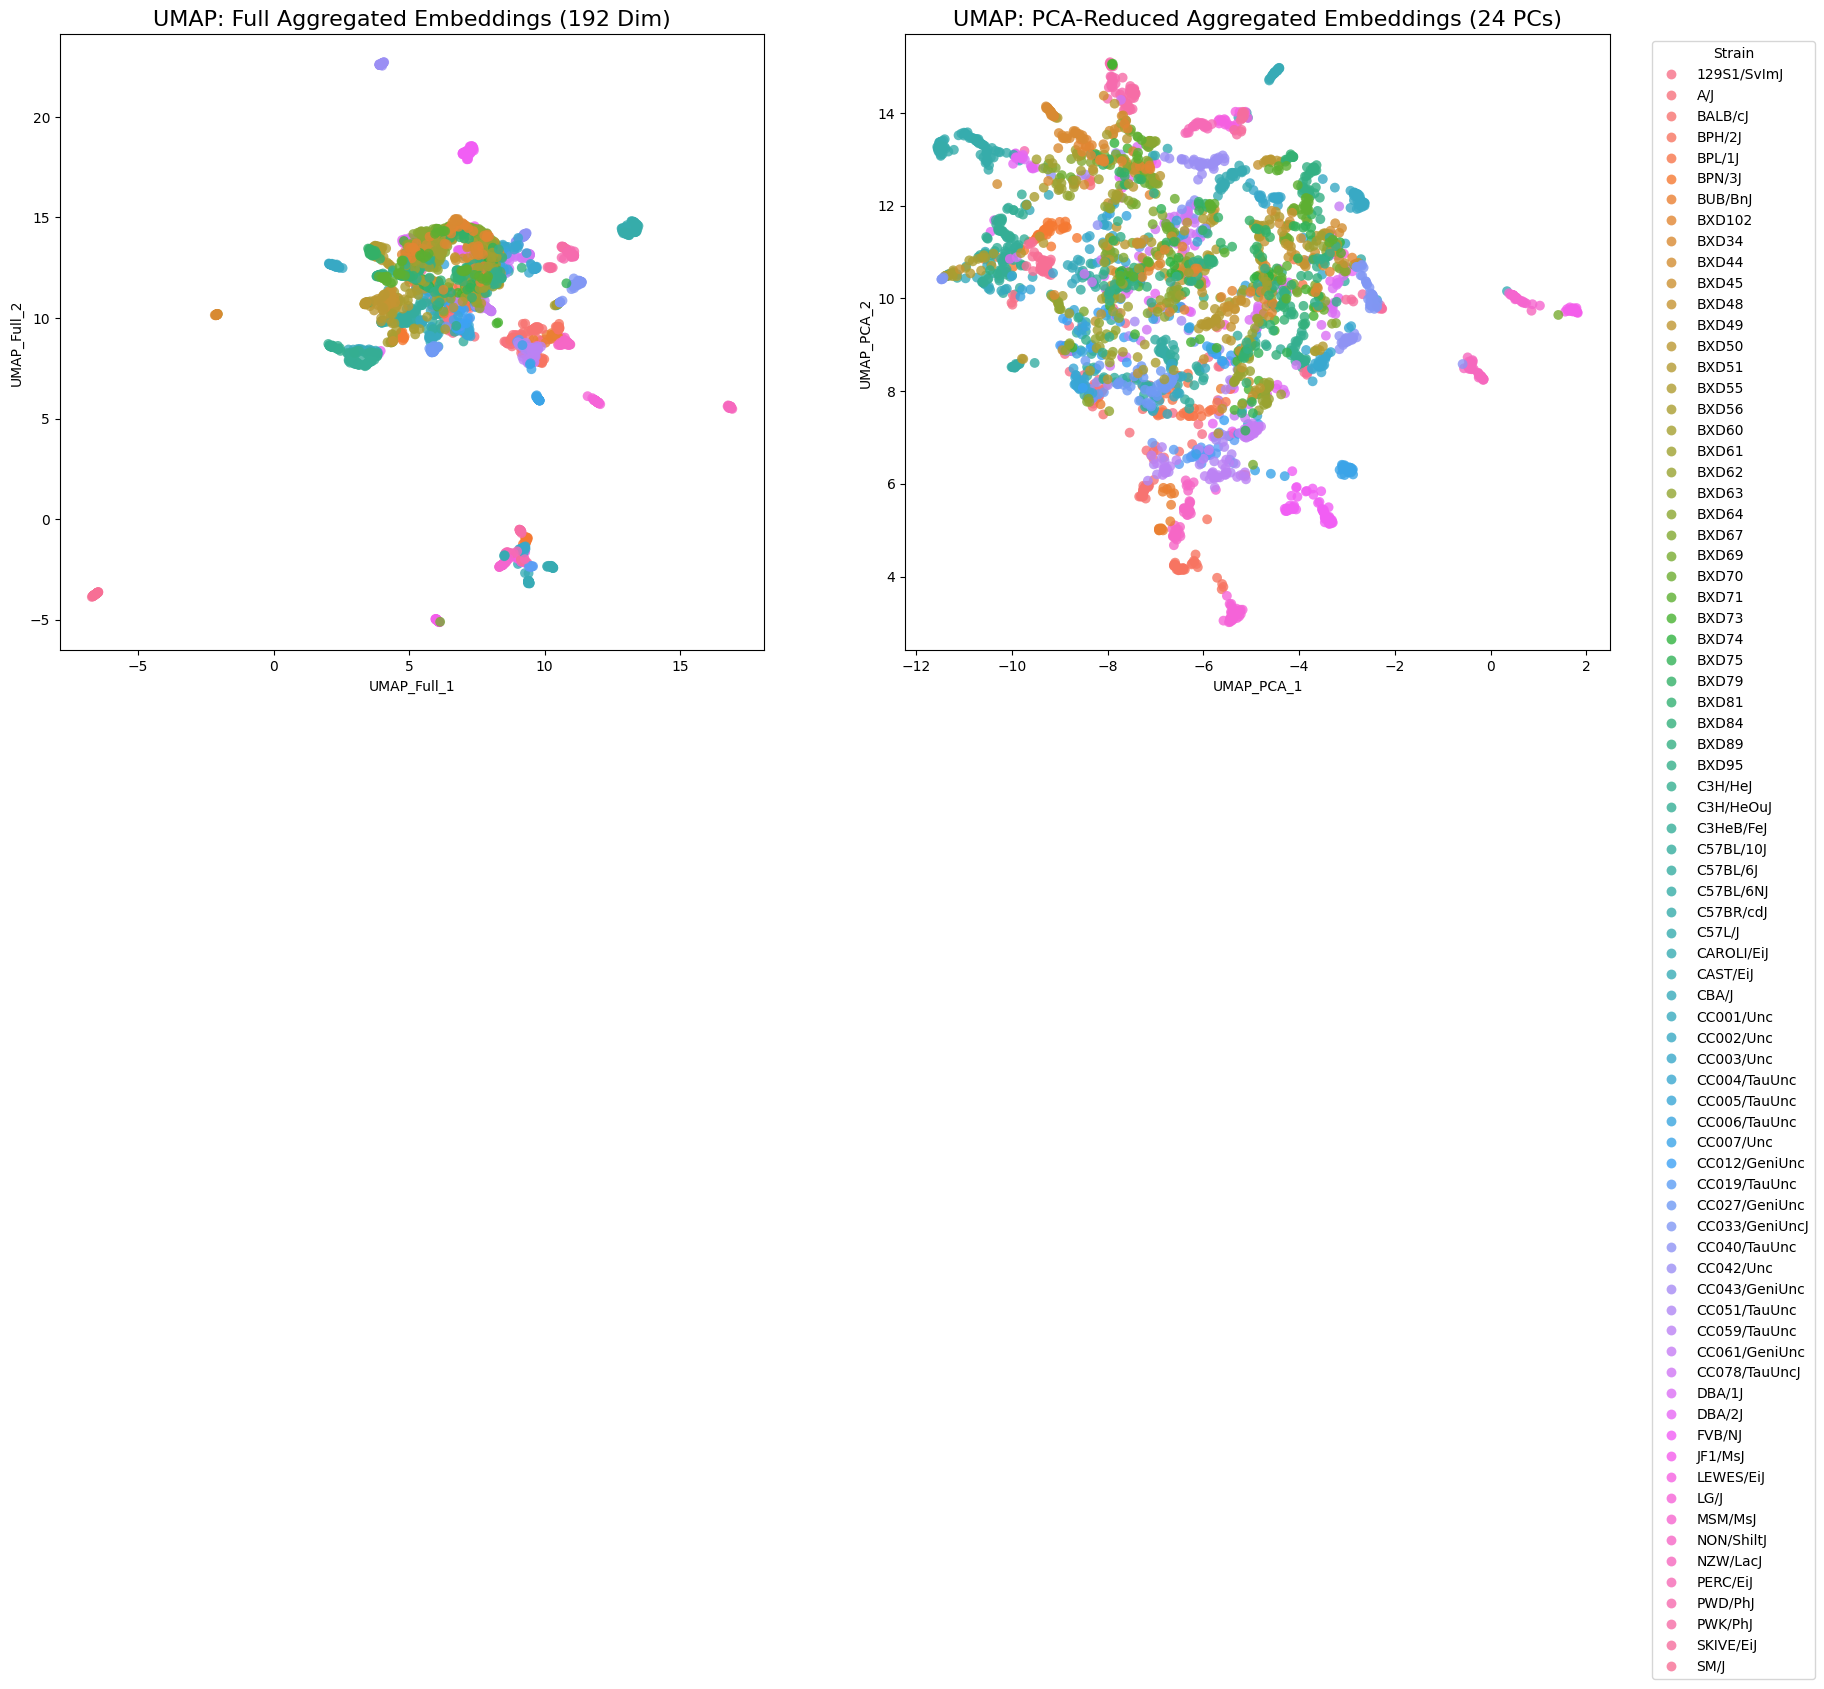

In [6]:
# %% [markdown]
# # Step 3: UMAP Visualization (Full vs. PCA-Reduced)
# This cell compares the 2D UMAP projections of the full aggregated embeddings 
# against the PCA-reduced aggregated embeddings, colored by strain.

# %%
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Configuration ---
N_COMPONENTS = 24      # Ensure this matches what you decided in Cell 2
AGG_METHOD = "mean"    # 'mean' or 'median'
META_TSV_PATH = "/scratch/michal/projects/dvc_ofd_2025/data/raw/openfield_ORT/hdp_meta.tsv"

print(f"1. Calculating {AGG_METHOD.capitalize()} pooled embeddings (Full & PCA-Reduced)...")
full_emb_list = []
pca_emb_list = []
meta_info_list = []

for vid, frames in frame_dict.items():
    # 1. Full Frame Pooling
    if AGG_METHOD == "mean":
        full_agg = np.mean(frames, axis=0)
    else:
        full_agg = np.median(frames, axis=0)
        
    # 2. PCA-Reduced Frame Pooling
    # Transform using the pipeline from Cell 1, slice the top N components
    reduced_frames = pca_pipeline.transform(frames)[:, :N_COMPONENTS]
    if AGG_METHOD == "mean":
        pca_agg = np.mean(reduced_frames, axis=0)
    else:
        pca_agg = np.median(reduced_frames, axis=0)
        
    parts = vid.split('_')
    if len(parts) >= 3:
        meta_info_list.append({
            'video_name': vid,
            'animal_id': parts[0]
        })
        full_emb_list.append(full_agg)
        pca_emb_list.append(pca_agg)

# Convert to DataFrames and arrays
df_meta = pd.DataFrame(meta_info_list)
X_full = np.vstack(full_emb_list)
X_pca = np.vstack(pca_emb_list)

print("2. Merging with metadata and filtering...")
meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()

master_df = pd.merge(df_meta, meta_df, on='animal_id', how='inner')

# Filter exactly as we did for classification
valid_idx = master_df['strain'].notna() & (master_df['strain'] != 'B6CAST-129SPWK-F2')
master_df = master_df[valid_idx]
X_full = X_full[valid_idx]
X_pca = X_pca[valid_idx]

counts = master_df['strain'].value_counts()
valid_strains = counts[counts >= 20].index

final_idx = master_df['strain'].isin(valid_strains)
master_df = master_df[final_idx].reset_index(drop=True)
X_full = X_full[final_idx]
X_pca = X_pca[final_idx]

print(f"Valid recordings for UMAP: {len(master_df)} (across {len(valid_strains)} strains)")

print("\n3. Running UMAP...")
# UMAP is distance-based, so it's best practice to scale the pooled embeddings before reducing to 2D
scaler_full = StandardScaler()
scaler_pca = StandardScaler()

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

print(" -> Projecting Full Embeddings...")
umap_full = umap_model.fit_transform(scaler_full.fit_transform(X_full))

print(" -> Projecting PCA-Reduced Embeddings...")
umap_pca = umap_model.fit_transform(scaler_pca.fit_transform(X_pca))

master_df['UMAP_Full_1'] = umap_full[:, 0]
master_df['UMAP_Full_2'] = umap_full[:, 1]
master_df['UMAP_PCA_1'] = umap_pca[:, 0]
master_df['UMAP_PCA_2'] = umap_pca[:, 1]

print("\n4. Plotting...")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Define a consistent color palette for both plots
strains = master_df['strain'].unique()
palette = sns.color_palette("husl", len(strains))
hue_order = sorted(strains)

# Plot 1: Full Embeddings
sns.scatterplot(
    data=master_df, x='UMAP_Full_1', y='UMAP_Full_2', 
    hue='strain', palette=palette, hue_order=hue_order, 
    ax=axes[0], alpha=0.8, s=50, edgecolor='none'
)
axes[0].set_title(f"UMAP: Full Aggregated Embeddings ({X_full.shape[1]} Dim)", fontsize=16)
axes[0].legend_.remove() # Remove legend from the first plot to save space

# Plot 2: PCA-Reduced Embeddings
sns.scatterplot(
    data=master_df, x='UMAP_PCA_1', y='UMAP_PCA_2', 
    hue='strain', palette=palette, hue_order=hue_order, 
    ax=axes[1], alpha=0.8, s=50, edgecolor='none'
)
axes[1].set_title(f"UMAP: PCA-Reduced Aggregated Embeddings ({N_COMPONENTS} PCs)", fontsize=16)
axes[1].legend(title='Strain', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()